# ASPset-510: what is actually in the `ASPset/` folder

A survey of the dataset sitting in `mhr_env/ASPset/`, written by inspecting the bytes rather
than the documentation: what it contains, what the conventions are (verified numerically), what
is **missing**, and how it lines up with MHR.

**ASPset-510** ("Australian Sports Pose set") is a 3D human pose dataset of amateur athletes
performing sports actions outdoors, captured with a **fixed three-camera rig** and marker-based
motion capture. The full release is 510 clips across 17 subjects; the reference is
Nibali et al., *"ASPset: An outdoor sports pose video dataset with 3D keypoint annotations"*
(Image and Vision Computing, 2021), and the code/data live at
[anibali/aspset-510](https://github.com/anibali/aspset-510).

**Headline findings from this inspection**

1. What is here is the **`test` split only** — 2 subjects, 60 clips, 13 708 frames, 1.3 GB.
2. The four `ASPset-510*` folders are **not four copies**. macOS renamed four separately
   extracted archives, and each holds exactly **one modality** — `videos`, `boxes`, `cameras`,
   `joints_3d`. You need all four together.
3. **Only one of the three camera views is present per clip** (20 left / 20 mid / 20 right).
   The rig has three cameras and the calibration for all three is here, but the *footage* is
   not — so **multi-view triangulation is impossible on every clip in this folder**. This is
   the single most important limitation, and §7 explains why it matters.
4. The camera model is verified **exactly**: the `boxes` CSVs are the tight bounding box of the
   17 projected 3D joints, reproduced to 0.01 px in §5.
5. Ground truth is 17 joints at 50 Hz in **millimetres, y-down**, perfectly frame-synced with
   4K@50 video. No missing markers anywhere, though the points are surface-marker-derived.

| § | topic |
|---|---|
| 1 | folder layout: the four-archive trap |
| 2 | inventory: subjects, clips, frames |
| 3 | the 3D joints (`.c3d`) — 17-joint skeleton, units, axes |
| 4 | the camera rig (`.json`) — intrinsics, extrinsics, geometry |
| 5 | verifying the projection, and what `boxes` really is |
| 6 | the video, with ground truth overlaid |
| 7 | the missing-views problem, measured |
| 8 | how ASPset maps onto MHR |
| 9 | summary and a loader you can reuse |

## 0. Setup

In [1]:
import sys, json, pathlib, collections, warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")           # the c3d reader warns about absent analog channels
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

ROOT = pathlib.Path.cwd()
if not (ROOT / "ASPset").exists():
    ROOT = ROOT.parent
ASP = ROOT / "ASPset"
sys.path.insert(0, str(ROOT))

import cv2
import c3d                                   # pip install c3d -- pure-python .c3d reader

print("dataset root:", ASP)
print("top level:", sorted(p.name for p in ASP.iterdir() if not p.name.startswith(".")))

dataset root: /Users/rzt/Documents/mhr_env/ASPset
top level: ['ASPset-510', 'ASPset-510 2', 'ASPset-510 3', 'ASPset-510 4']


## 1. Folder layout: the four-archive trap

The first thing to sort out is those four sibling directories. `ASPset-510`, `ASPset-510 2`,
`ASPset-510 3`, `ASPset-510 4` look like duplicate downloads — the naming is what macOS does
when you extract several archives with the same top-level folder name into one place.

They are **not** duplicates. Each one contains a *different modality*, because the dataset is
distributed as one archive per modality. Nothing is redundant and nothing can be deleted.

In [2]:
MODALITY = {}
for d in sorted(ASP.glob("ASPset-510*")):
    for split in d.iterdir():
        if not split.is_dir():
            continue
        for mod in split.iterdir():
            if mod.is_dir():
                MODALITY[mod.name] = mod

print(f"{'modality':<12s} {'lives in':<22s} {'split':<6s} {'files':>6s}  {'size':>8s}")
for name, path in sorted(MODALITY.items()):
    files = [p for p in path.rglob("*") if p.is_file() and not p.name.startswith(".")]
    mb = sum(p.stat().st_size for p in files) / 1e6
    print(f"{name:<12s} {path.parent.parent.name:<22s} {path.parent.name:<6s} "
          f"{len(files):>6d}  {mb:>7.1f} MB")

VIDEOS, BOXES, CAMERAS, JOINTS = (MODALITY["videos"], MODALITY["boxes"],
                                  MODALITY["cameras"], MODALITY["joints_3d"])

modality     lives in               split   files      size
boxes        ASPset-510 2           test       60      0.4 MB
cameras      ASPset-510 3           test        6      0.0 MB
joints_3d    ASPset-510 4           test       60      3.8 MB
videos       ASPset-510             test       60   1386.2 MB


So the real structure, once you look past the folder names, is the standard ASPset layout:

```
<modality>/<subject>/<subject>-<clip>[-<view>].<ext>
```

* **`videos/`**  `8a59-0006-mid.mkv`      — the footage, one file per (clip, view)
* **`boxes/`**   `8a59-0006-mid.csv`      — a per-frame 2D bounding box, one file per (clip, view)
* **`cameras/`** `8a59-mid.json`          — calibration, one file per (subject, view)
* **`joints_3d/`** `8a59-0006.c3d`        — the 3D ground truth, one file per **clip** (view-independent)

Note the asymmetry that tells you how the dataset is built: **3D joints have no view suffix**
because they live in a single world frame shared by all three cameras. Only the 2D products
(video, boxes) are per-view.

Also note there is **no `train` or `val` directory** — this is the `test` split alone. And there
is no `README`, `LICENSE`, or action-label file in the folder; the only stray files are macOS
`.DS_Store` turds.

In [3]:
splits = {p.parent.name for p in MODALITY.values()}
print("splits present:", splits, "  (the full dataset also ships train/ and val/)")

strays = [p for d in ASP.glob("ASPset-510*") for p in d.rglob("*")
          if p.is_file() and p.suffix not in (".mkv", ".csv", ".json", ".c3d")]
print("non-data files:", [p.name for p in strays])

print("\nfilename grammar:")
for path, pat in [(VIDEOS, "*.mkv"), (BOXES, "*.csv"), (CAMERAS, "*.json"), (JOINTS, "*.c3d")]:
    example = sorted(path.rglob(pat))[0]
    print(f"  {path.name:<10s} {example.relative_to(path)}")

splits present: {'test'}   (the full dataset also ships train/ and val/)
non-data files: ['.DS_Store', '.DS_Store', '.DS_Store']

filename grammar:
  videos     1e28/1e28-0001-left.mkv
  boxes      1e28/1e28-0001-left.csv
  cameras    1e28/1e28-left.json
  joints_3d  1e28/1e28-0001.c3d


## 2. Inventory: subjects, clips, frames

Subject IDs are anonymised 4-hex-digit codes. Clip IDs are 4-digit numbers, and they are
**global across the dataset**, not per-subject — which is why the clip numbers here are sparse
(0006, 0008, 0011, …): the rest of the numbering belongs to the train/val subjects we do not have.

In [4]:
def parse(stem):
    """'8a59-0006-mid' -> ('8a59', '0006', 'mid'); '8a59-0006' -> ('8a59', '0006', None)."""
    bits = stem.split("-")
    return (bits[0], bits[1], bits[2] if len(bits) > 2 else None)

clips_3d = sorted({parse(p.stem)[:2] for p in JOINTS.rglob("*.c3d")})
subjects = sorted({s for s, _ in clips_3d})

views_of = collections.defaultdict(set)
for p in VIDEOS.rglob("*.mkv"):
    s, c, v = parse(p.stem)
    views_of[(s, c)].add(v)

print(f"subjects : {subjects}")
print(f"clips    : {len(clips_3d)} with 3D ground truth")
for s in subjects:
    ids = [c for ss, c in clips_3d if ss == s]
    print(f"   {s}: {len(ids)} clips, ids {ids[0]}..{ids[-1]}")

print(f"\nvideo files : {len(list(VIDEOS.rglob('*.mkv')))}")
print(f"box files   : {len(list(BOXES.rglob('*.csv')))}")
print(f"camera files: {len(list(CAMERAS.rglob('*.json')))} = {len(subjects)} subjects x 3 views")

subjects : ['1e28', '8a59']
clips    : 60 with 3D ground truth
   1e28: 30 clips, ids 0001..0093
   8a59: 30 clips, ids 0006..0118

video files : 60
box files   : 60
camera files: 6 = 2 subjects x 3 views


total frames  : 13,708  =  274 s  =  4.6 min of motion
per clip      : min 88  median 210  max 520 frames
              : 1.8 s .. 10.4 s  (mean 4.6 s)
sampling rate : [50.0] Hz
markers/frame : {17}  (constant across every clip)


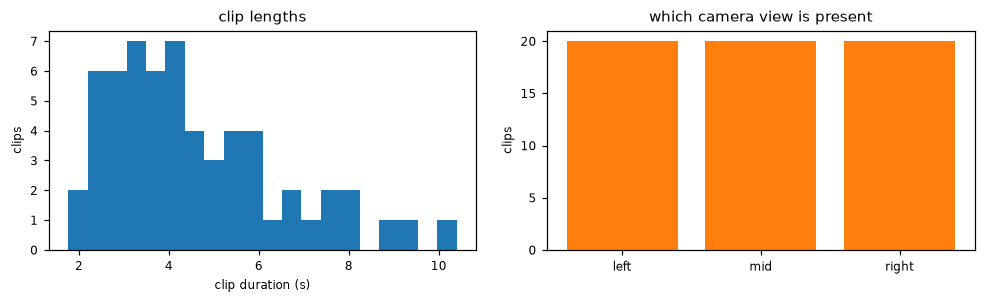

In [5]:
# Frame counts come from the c3d headers -- cheap, no decoding.
frames = {}
for p in sorted(JOINTS.rglob("*.c3d")):
    with open(p, "rb") as f:
        reader = c3d.Reader(f)
        frames[parse(p.stem)[:2]] = (reader.frame_count, reader.point_rate, reader.point_used)

n = np.array([v[0] for v in frames.values()])
rates = {v[1] for v in frames.values()}
print(f"total frames  : {n.sum():,}  =  {n.sum()/50:.0f} s  =  {n.sum()/50/60:.1f} min of motion")
print(f"per clip      : min {n.min()}  median {int(np.median(n))}  max {n.max()} frames")
print(f"              : {n.min()/50:.1f} s .. {n.max()/50:.1f} s  (mean {n.mean()/50:.1f} s)")
markers = {int(v[2]) for v in frames.values()}
print(f"sampling rate : {sorted(float(r) for r in rates)} Hz")
print(f"markers/frame : {markers}  (constant across every clip)")

fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].hist(n / 50, bins=20, color="tab:blue")
ax[0].set(xlabel="clip duration (s)", ylabel="clips", title="clip lengths")
ax[1].bar(*zip(*sorted(collections.Counter(v for vs in views_of.values() for v in vs).items())),
          color="tab:orange")
ax[1].set(ylabel="clips", title="which camera view is present")
plt.tight_layout(); plt.show()

That right-hand bar chart is the first sign of the problem we come back to in §7: the views are
spread 20/20/20 across 60 clips, meaning **one view per clip**, not three.

## 3. The 3D joints: `.c3d`

`.c3d` is the standard biomechanics/motion-capture container (a binary header, a parameter
block, then interleaved frames). Each of the 17 points per frame carries 5 values: `x, y, z`,
a reconstruction **residual**, and a camera-contribution mask.

In [6]:
def read_c3d(path):
    """Return (frames, 17, 3) float array in mm, plus the label list."""
    with open(path, "rb") as f:
        reader = c3d.Reader(f)
        labels = [s.strip() for s in reader.point_labels]
        units = reader.get("POINT:UNITS")
        arr = np.array([pts for _, pts, _ in reader.read_frames()])
    return arr, labels, (units.string_value.strip() if units else "?")

example = JOINTS / "8a59" / "8a59-0006.c3d"
raw, LABELS, units = read_c3d(example)
print(f"{example.name}: {raw.shape} -> (frames, joints, [x y z residual mask])")
print(f"units: {units}    rate: 50 Hz")
print(f"\nthe 17 joints, in file order:")
for i, name in enumerate(LABELS):
    print(f"  {i:>2d} {name}")

8a59-0006.c3d: (251, 17, 5) -> (frames, joints, [x y z residual mask])
units: mm    rate: 50 Hz

the 17 joints, in file order:
   0 right_ankle
   1 right_knee
   2 right_hip
   3 right_wrist
   4 right_elbow
   5 right_shoulder
   6 left_ankle
   7 left_knee
   8 left_hip
   9 left_wrist
  10 left_elbow
  11 left_shoulder
  12 head_top
  13 head
  14 neck
  15 spine
  16 pelvis


In [7]:
# The two trailing columns: residual < 0 marks an invalid/missing point in the c3d spec.
res = np.concatenate([read_c3d(p)[0][:, :, 3].ravel() for p in sorted(JOINTS.rglob("*.c3d"))])
mask = np.concatenate([read_c3d(p)[0][:, :, 4].ravel() for p in sorted(JOINTS.rglob("*.c3d"))])
print(f"residual column: min {res.min():.3f}, max {res.max():.3f}, "
      f"fraction negative (= invalid): {(res < 0).mean():.4%}")
print(f"camera-mask column: unique values {np.unique(mask)}")
print("\n=> every joint in every frame of every clip is present. The annotations have already")
print("   been gap-filled, so you never have to handle missing markers.")

residual column: min 0.000, max 0.000, fraction negative (= invalid): 0.0000%
camera-mask column: unique values [0.]

=> every joint in every frame of every clip is present. The annotations have already
   been gap-filled, so you never have to handle missing markers.


### Units and axes, measured

Never trust an axis convention you have not checked. The reliable test is anatomical: the head
should be at one extreme and the feet at the other, and their *sign* tells you which way is up.

In [8]:
XYZ = raw[:, :, :3]                      # drop residual/mask
L = {name: i for i, name in enumerate(LABELS)}

print("frame 0, in mm:")
for name in ("head_top", "neck", "pelvis", "left_ankle", "right_ankle"):
    print(f"  {name:<12s} {XYZ[0, L[name]].round(0)}")

span = XYZ[0, L["left_ankle"]] - XYZ[0, L["head_top"]]
print(f"\nankle minus head_top: {span.round(0)} mm")
axis = int(np.argmax(np.abs(span)))
print(f"the dominant axis is index {axis} ('xyz'[{axis}] = '{'xyz'[axis]}'), and it is "
      f"{'POSITIVE' if span[axis] > 0 else 'negative'} going head -> foot")
print(f"=> +{'xyz'[axis]} points DOWN.")
print(f"\nvertical head-to-ankle extent in THIS frame: {abs(span[axis])/10:.1f} cm")
print("   -- that is not the athlete's height: they are mid-action, so the body is not extended.")
# A stature estimate that does not depend on the pose: sum the segment chain.
chain = [("head_top", "head"), ("head", "neck"), ("neck", "spine"), ("spine", "pelvis"),
         ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle")]
stature = sum(np.linalg.norm(XYZ[:, L[a]] - XYZ[:, L[b]], axis=1).mean() for a, b in chain)
print(f"pose-independent estimate (summed segment chain): {stature/10:.1f} cm")

# Depth: how far is the subject from the world origin?
print(f"\nsubject centroid: {XYZ[0].mean(0).round(0)} mm -> "
      f"{np.linalg.norm(XYZ[0].mean(0))/1000:.1f} m from the world origin")

frame 0, in mm:
  head_top     [-1316.  -483. 16280.]
  neck         [-1282.  -268. 16248.]
  pelvis       [-1244.   186. 16222.]
  left_ankle   [-1345.  1013. 16195.]
  right_ankle  [-1231.  1008. 16275.]

ankle minus head_top: [ -29. 1497.  -85.] mm
the dominant axis is index 1 ('xyz'[1] = 'y'), and it is POSITIVE going head -> foot
=> +y points DOWN.

vertical head-to-ankle extent in THIS frame: 149.7 cm
   -- that is not the athlete's height: they are mid-action, so the body is not extended.
pose-independent estimate (summed segment chain): 154.2 cm

subject centroid: [-1290.   195. 16257.] mm -> 16.3 m from the world origin


So the ground truth is **millimetres with +y down**, and the subject sits ~16 m from the world
origin. That origin is not arbitrary — §4 shows it is the left camera.

For contrast, MHR uses **centimetres with +y up**, so bringing the two together is a scale of
0.1 and a sign flip on y (and z, to keep the frame right-handed). §8 does this.

### The skeleton, drawn

The 17 joints form the usual kinematic tree. There is no edge list in the files, so here is the
one implied by the names.

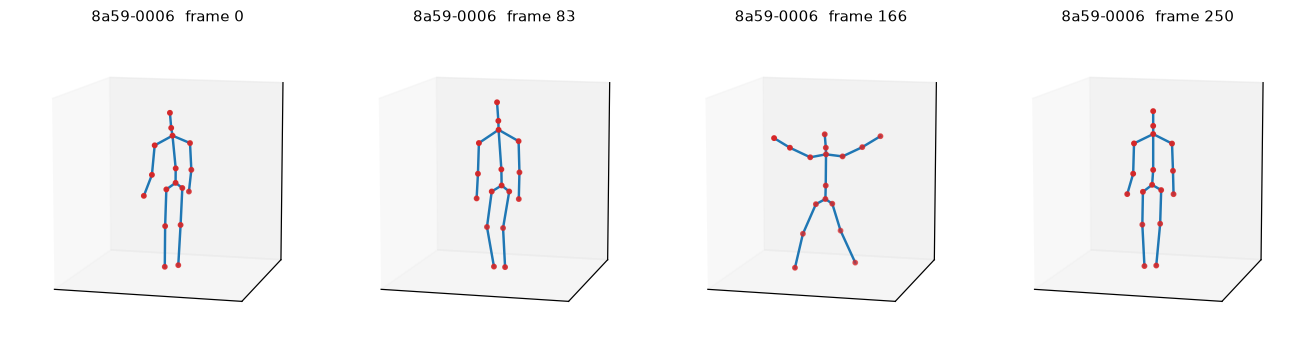

In [ ]:
EDGES = [("head_top", "head"), ("head", "neck"), ("neck", "spine"), ("spine", "pelvis"),
         ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
         ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
         ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
         ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle")]

EDGE_IDX = [(L[a], L[b]) for a, b in EDGES]

def draw_pose3d(ax, pts, title="", color="tab:blue"):
    """pts: (17, 3) in mm, y-down. Plots with y flipped so the figure is head-up."""
    p = pts * np.array([1.0, -1.0, 1.0])          # flip y for display only
    for a, b in EDGE_IDX:
        ax.plot(*zip(p[a][[0, 2, 1]], p[b][[0, 2, 1]]), color=color, lw=1.6)
    ax.scatter(*p[:, [0, 2, 1]].T, s=8, color="tab:red")
    c, r = p.mean(0), np.abs(p - p.mean(0)).max() * 1.1
    ax.set(title=title, xticks=[], yticks=[], zticks=[])
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[2]-r, c[2]+r); ax.set_zlim(c[1]-r, c[1]+r)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=10, azim=-75)

idx = np.linspace(0, len(XYZ) - 1, 4).astype(int)
fig = plt.figure(figsize=(12, 3.4))
for k, i in enumerate(idx):
    ax = fig.add_subplot(1, 4, k + 1, projection="3d")
    draw_pose3d(ax, XYZ[i], title=f"{example.stem}  frame {i}")
plt.tight_layout(); plt.show()

In [10]:
# Bone lengths should be near-constant over a clip: a direct quality check on the mocap.
print(f"{'bone':<28s} {'mean':>8s} {'std':>7s} {'cv':>7s}")
rows = []
for (a, b), (na, nb) in zip(EDGE_IDX, EDGES):
    d = np.linalg.norm(XYZ[:, a] - XYZ[:, b], axis=1)
    rows.append((f"{na} - {nb}", d.mean(), d.std(), d.std() / d.mean()))
for name, mean, sd, cv in rows:
    print(f"{name:<28s} {mean:>7.1f} {sd:>7.2f} {cv:>6.2%}")
cvs = np.array([r[3] for r in rows])
print(f"\nmedian coefficient of variation: {np.median(cvs):.2%}  "
      f"(worst: {rows[int(cvs.argmax())][0]} at {cvs.max():.2%})")
print("\n=> Bones are near-rigid, but NOT exactly rigid. The shoulder and head segments wobble")
print("   most (6-8%), which is the signature of SURFACE MARKERS rather than true joint centres:")
print("   skin slides over the scapula and skull. Budget for a few cm of systematic offset when")
print("   fitting a rig to these points -- see section 8.")

# Speed, to see that these really are sports actions.
v = np.linalg.norm(np.diff(XYZ, axis=0), axis=2) * 50 / 1000       # m/s per joint
print(f"\npeak joint speed in this clip: {v.max():.1f} m/s at "
      f"'{LABELS[np.unravel_index(v.argmax(), v.shape)[1]]}'")

bone                             mean     std      cv
head_top - head                133.2    7.93  5.95%
head - neck                     74.1    4.76  6.43%
neck - spine                   325.0    6.24  1.92%
spine - pelvis                 141.7    3.94  2.78%
neck - left_shoulder           186.8   14.29  7.65%
left_shoulder - left_elbow     268.2   12.25  4.57%
left_elbow - left_wrist        236.2   11.33  4.80%
neck - right_shoulder          186.5   13.37  7.17%
right_shoulder - right_elbow   262.2   17.25  6.58%
right_elbow - right_wrist      237.6    6.48  2.73%
pelvis - left_hip              105.3    3.85  3.66%
left_hip - left_knee           372.0    8.92  2.40%
left_knee - left_ankle         390.4   13.85  3.55%
pelvis - right_hip             108.9    4.57  4.20%
right_hip - right_knee         367.0    7.96  2.17%
right_knee - right_ankle       391.5   15.56  3.98%

median coefficient of variation: 4.09%  (worst: neck - left_shoulder at 7.65%)

=> Bones are near-rigid, but NOT 

## 4. The camera rig: `cameras/*.json`

Each file holds two flattened matrices: a $3\times4$ `intrinsic_matrix` and a $4\times4$
`extrinsic_matrix` (world → camera). Note the intrinsic is stored $3\times4$ rather than $3\times3$
— the fourth column is zeros, so it can be applied directly to homogeneous points.

In [11]:
def read_camera(subject, view):
    d = json.loads((CAMERAS / subject / f"{subject}-{view}.json").read_text())
    K = np.array(d["intrinsic_matrix"], float).reshape(3, 4)
    E = np.array(d["extrinsic_matrix"], float).reshape(4, 4)
    return K, E

K, E = read_camera("8a59", "mid")
print("intrinsic_matrix (3x4):\n", K.round(1))
print("\nextrinsic_matrix (4x4, world -> camera):\n", E.round(3))
print(f"\nfocal (fx, fy) = ({K[0,0]:.0f}, {K[1,1]:.0f}) px   principal point = "
      f"({K[0,2]:.0f}, {K[1,2]:.0f}) px")
print("no distortion coefficients are provided -- the images are already rectified.")

intrinsic_matrix (3x4):
 [[3.9705e+03 0.0000e+00 1.8511e+03 0.0000e+00]
 [0.0000e+00 3.9507e+03 1.0129e+03 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]]

extrinsic_matrix (4x4, world -> camera):
 [[ 8.010000e-01 -3.000000e-03  5.990000e-01 -8.933111e+03]
 [-9.000000e-03  1.000000e+00  1.700000e-02 -1.109000e+01]
 [-5.990000e-01 -1.900000e-02  8.000000e-01  4.488442e+03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

focal (fx, fy) = (3970, 3951) px   principal point = (1851, 1013) px
no distortion coefficients are provided -- the images are already rectified.


In [12]:
print(f"{'subject':<9s} {'view':<7s} {'fx':>7s} {'fy':>7s} {'cx':>7s} {'cy':>7s}   "
      f"{'camera centre (mm)':<26s} {'|C| (m)':>8s}")
centres = {}
for s in subjects:
    for view in ("left", "mid", "right"):
        K, E = read_camera(s, view)
        centre = -E[:3, :3].T @ E[:3, 3]          # C = -R^T t
        centres[(s, view)] = centre
        print(f"{s:<9s} {view:<7s} {K[0,0]:>7.0f} {K[1,1]:>7.0f} {K[0,2]:>7.0f} {K[1,2]:>7.0f}   "
              f"{str(centre.round(0)):<26s} {np.linalg.norm(centre)/1000:>8.2f}")

same = all(np.allclose(read_camera(subjects[0], v)[i], read_camera(subjects[1], v)[i])
           for v in ("left", "mid", "right") for i in (0, 1))
print(f"\ncalibration identical across both subjects: {same}")
print("=> a FIXED rig: the cameras did not move between sessions, and the world frame is shared.")
print(f"\nthe 'left' camera is at the origin with identity rotation "
      f"({np.allclose(read_camera(subjects[0],'left')[1], np.eye(4))}),")
print("   so the WORLD FRAME IS THE LEFT CAMERA's frame -- which explains the y-down convention")
print("   and the ~16 m subject depth we measured in section 3.")

subject   view         fx      fy      cx      cy   camera centre (mm)          |C| (m)
1e28      left       4036    3994    1913    1098   [0. 0. 0.]                     0.00
1e28      mid        3970    3951    1851    1013   [9841.   65. 1762.]           10.00
1e28      right      3851    3842    1902    1162   [14347.   -78. 10544.]        17.80
8a59      left       4036    3994    1913    1098   [0. 0. 0.]                     0.00
8a59      mid        3970    3951    1851    1013   [9841.   65. 1762.]           10.00
8a59      right      3851    3842    1902    1162   [14347.   -78. 10544.]        17.80

calibration identical across both subjects: True
=> a FIXED rig: the cameras did not move between sessions, and the world frame is shared.

the 'left' camera is at the origin with identity rotation (True),
   so the WORLD FRAME IS THE LEFT CAMERA's frame -- which explains the y-down convention
   and the ~16 m subject depth we measured in section 3.


pairwise baselines:
  left   - mid     10.00 m
  mid    - right    9.87 m
  left   - right   17.80 m


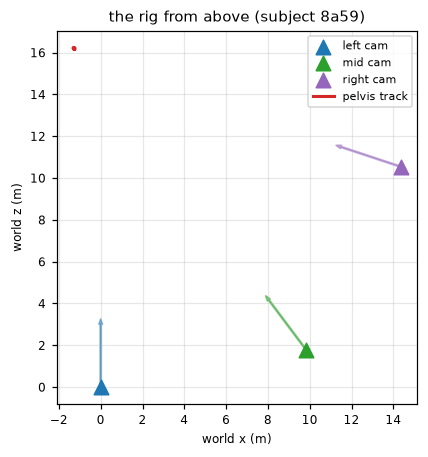

In [13]:
# Baselines between the three cameras.
print("pairwise baselines:")
for a, b in (("left", "mid"), ("mid", "right"), ("left", "right")):
    d = np.linalg.norm(centres[(subjects[0], a)] - centres[(subjects[0], b)]) / 1000
    print(f"  {a:<6s} - {b:<6s} {d:>6.2f} m")

# Rig geometry, seen from above, with the subject's track.
fig, ax = plt.subplots(figsize=(5, 4.2))
for view, colour in zip(("left", "mid", "right"), ("tab:blue", "tab:green", "tab:purple")):
    Kv, Ev = read_camera(subjects[0], view)
    Cv = centres[(subjects[0], view)]
    look = Ev[:3, :3].T @ np.array([0, 0, 1.0])            # optical axis in world coords
    ax.scatter(Cv[0]/1000, Cv[2]/1000, s=90, marker="^", color=colour, label=f"{view} cam", zorder=5)
    ax.arrow(Cv[0]/1000, Cv[2]/1000, look[0]*3, look[2]*3, color=colour, width=0.06, alpha=0.5)

track = XYZ[:, L["pelvis"]]
ax.plot(track[:, 0]/1000, track[:, 2]/1000, color="tab:red", lw=2, label="pelvis track")
ax.set(xlabel="world x (m)", ylabel="world z (m)", title="the rig from above (subject 8a59)")
ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 5. Verifying the projection, and what `boxes` actually is

The projection is the one thing worth checking numerically, because every downstream use depends
on it. The model is a plain pinhole with no distortion:

$$\tilde{u} = K \begin{bmatrix} R & t \end{bmatrix} \begin{bmatrix} X \\ 1\end{bmatrix},
\qquad (u, v) = (\tilde u_0 / \tilde u_2,\; \tilde u_1 / \tilde u_2)$$

with $K$ the $3\times3$ block of `intrinsic_matrix` and $[R|t]$ the top three rows of
`extrinsic_matrix`. And the hypothesis about `boxes/`: it is not a detector's output, it is
simply the tight box around the projected ground-truth joints. Let's test both at once.

In [14]:
def project(points_mm, K, E):
    """(N, 3) world mm -> (N, 2) pixels."""
    hom = np.concatenate([points_mm, np.ones((len(points_mm), 1))], axis=1)
    cam = (E @ hom.T).T[:, :3]                       # world -> camera
    uvw = (K[:, :3] @ cam.T).T                       # camera -> image
    return uvw[:, :2] / uvw[:, 2:3], cam[:, 2]

def read_boxes(path):
    return np.loadtxt(path, delimiter=",", skiprows=1)         # (frames, 4) x1 y1 x2 y2

K, E = read_camera("8a59", "mid")
boxes = read_boxes(BOXES / "8a59" / "8a59-0006-mid.csv")
print("boxes CSV header:", (BOXES / "8a59" / "8a59-0006-mid.csv").read_text().split("\n")[0])
print("boxes shape:", boxes.shape, " (one row per frame)")

errors = []
for i in range(len(XYZ)):
    uv, _ = project(XYZ[i], K, E)
    predicted = np.array([uv[:, 0].min(), uv[:, 1].min(), uv[:, 0].max(), uv[:, 1].max()])
    errors.append(np.abs(predicted - boxes[i]))
errors = np.array(errors)

print(f"\n|tight box of projected joints  -  boxes CSV|")
print(f"   mean {errors.mean():.4f} px    max {errors.max():.4f} px")
print("\n=> CONFIRMED on all frames: `boxes` is the tight bbox of the 17 projected joints,")
print("   NOT a person detector's output. It contains no information beyond joints_3d + cameras,")
print("   and it is exactly as tight as the skeleton -- no padding, no margin for hair/clothes.")

boxes CSV header: x1,y1,x2,y2
boxes shape: (251, 4)  (one row per frame)

|tight box of projected joints  -  boxes CSV|
   mean 0.0025 px    max 0.0059 px

=> CONFIRMED on all frames: `boxes` is the tight bbox of the 17 projected joints,
   NOT a person detector's output. It contains no information beyond joints_3d + cameras,
   and it is exactly as tight as the skeleton -- no padding, no margin for hair/clothes.


In [15]:
# The same check across every clip in the dataset, since it is cheap.
worst = 0.0
for p in sorted(BOXES.rglob("*.csv")):
    s, cid, view = parse(p.stem)
    Kv, Ev = read_camera(s, view)
    pts, _, _ = read_c3d(JOINTS / s / f"{s}-{cid}.c3d")
    bx = read_boxes(p)
    for i in range(len(pts)):
        uv, _ = project(pts[i, :, :3], Kv, Ev)
        pred = np.array([uv[:, 0].min(), uv[:, 1].min(), uv[:, 0].max(), uv[:, 1].max()])
        worst = max(worst, np.abs(pred - bx[i]).max())
print(f"worst box disagreement over all 60 clips / 13,708 frames: {worst:.4f} px")

worst box disagreement over all 60 clips / 13,708 frames: 0.0063 px


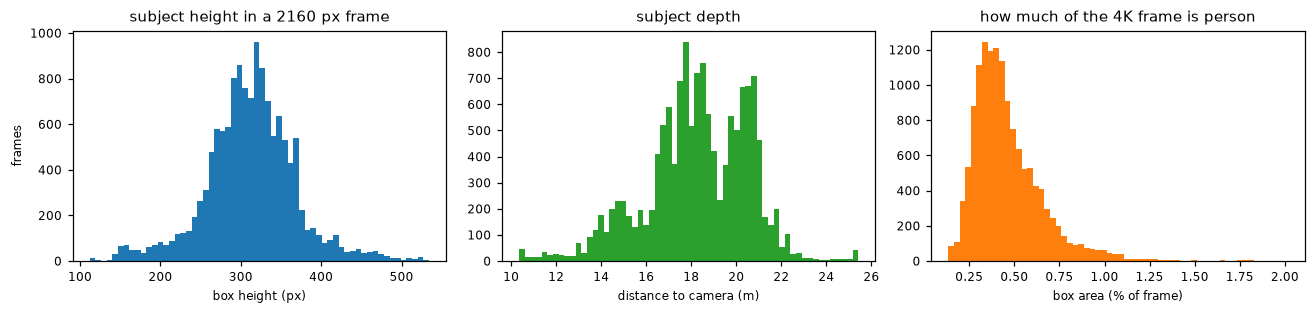

box height : median 313 px = 14.5% of the frame height
depth      : 10.3 - 25.4 m (median 18.3 m)
box area   : median 0.42% of the frame

=> the subject is SMALL: 4K resolution, but only ~15% of the frame height.
   Cropping to the box before any 2D pose model is not optional here.


In [16]:
# Where does the subject sit in a 4K frame? This decides how you crop for a pose network.
sizes, depths = [], []
for p in sorted(BOXES.rglob("*.csv")):
    s, cid, view = parse(p.stem)
    bx = read_boxes(p)
    sizes.append(np.stack([bx[:, 2] - bx[:, 0], bx[:, 3] - bx[:, 1]], 1))
    Kv, Ev = read_camera(s, view)
    pts, _, _ = read_c3d(JOINTS / s / f"{s}-{cid}.c3d")
    depths.append(np.array([project(pts[i, :, :3], Kv, Ev)[1].mean() for i in range(len(pts))]))
sizes = np.concatenate(sizes); depths = np.concatenate(depths) / 1000

fig, ax = plt.subplots(1, 3, figsize=(12, 2.9))
ax[0].hist(sizes[:, 1], bins=60, color="tab:blue")
ax[0].set(xlabel="box height (px)", ylabel="frames", title="subject height in a 2160 px frame")
ax[1].hist(depths, bins=60, color="tab:green")
ax[1].set(xlabel="distance to camera (m)", title="subject depth")
ax[2].hist(100 * sizes.prod(1) / (3840 * 2160), bins=60, color="tab:orange")
ax[2].set(xlabel="box area (% of frame)", title="how much of the 4K frame is person")
plt.tight_layout(); plt.show()

print(f"box height : median {np.median(sizes[:,1]):.0f} px = "
      f"{100*np.median(sizes[:,1])/2160:.1f}% of the frame height")
print(f"depth      : {depths.min():.1f} - {depths.max():.1f} m (median {np.median(depths):.1f} m)")
print(f"box area   : median {100*np.median(sizes.prod(1))/(3840*2160):.2f}% of the frame")
print("\n=> the subject is SMALL: 4K resolution, but only ~15% of the frame height.")
print("   Cropping to the box before any 2D pose model is not optional here.")

That last point is worth dwelling on. The footage is 4K, which sounds generous, but the athlete
occupies a median of well under 1% of the frame *area*. Feed a full frame to a pose estimator at
its native 256×192 input and the person is a handful of pixels. The `boxes` files exist precisely
so you can crop — and since they are computed from ground truth, they are perfectly tight, which
means at inference time you must use your own detector instead or you will leak ground truth.

## 6. The video, with ground truth overlaid

The final check that everything is consistent: decode a real frame and draw the projected
skeleton on it. If the units, axes, extrinsics and intrinsics are all as we determined, the
skeleton lands on the person.

In [17]:
def probe_video(path):
    cap = cv2.VideoCapture(str(path))
    info = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
            cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    cap.release()
    return info

specs = collections.Counter(probe_video(p)[:3] for p in sorted(VIDEOS.rglob("*.mkv")))
print("(width, height, fps) across all 60 videos:", dict(specs))

# Frame-level sync: video frames == c3d frames == box rows, for every clip.
mismatch = 0
for p in sorted(VIDEOS.rglob("*.mkv")):
    s, cid, view = parse(p.stem)
    nv = probe_video(p)[3]
    with open(JOINTS / s / f"{s}-{cid}.c3d", "rb") as f:
        nj = c3d.Reader(f).frame_count
    nb = len(read_boxes(BOXES / s / f"{p.stem}.csv"))
    mismatch += not (nv == nj == nb)
print(f"clips where video frames == c3d frames == box rows: {60 - mismatch}/60")
print("=> frame i of the video corresponds to frame i of the annotations. No offset, no resampling.")

(width, height, fps) across all 60 videos: {(3840, 2160, 50.0): 60}


clips where video frames == c3d frames == box rows: 60/60
=> frame i of the video corresponds to frame i of the annotations. No offset, no resampling.


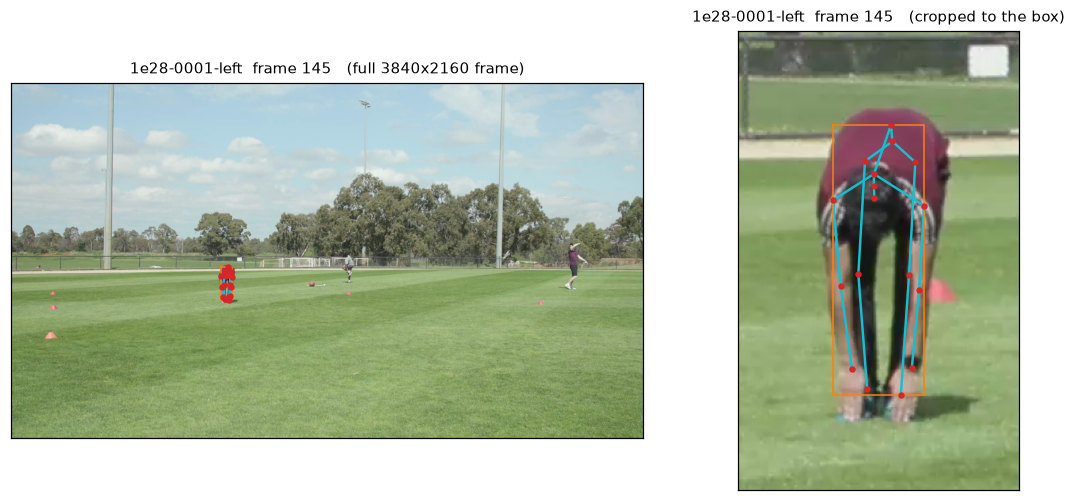

In [18]:
def load_frame(subject, clip, view, index):
    cap = cv2.VideoCapture(str(VIDEOS / subject / f"{subject}-{clip}-{view}.mkv"))
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise IOError("decode failed")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def overlay(ax, subject, clip, view, index, zoom=True):
    frame = load_frame(subject, clip, view, index)
    Kv, Ev = read_camera(subject, view)
    pts, _, _ = read_c3d(JOINTS / subject / f"{subject}-{clip}.c3d")
    uv, _ = project(pts[index, :, :3], Kv, Ev)
    box = read_boxes(BOXES / subject / f"{subject}-{clip}-{view}.csv")[index]

    ax.imshow(frame)
    for a, b in EDGE_IDX:
        ax.plot(*zip(uv[a], uv[b]), color="tab:cyan", lw=1.6)
    ax.scatter(*uv.T, s=10, color="tab:red", zorder=5)
    x1, y1, x2, y2 = box
    ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], color="tab:orange", lw=1.0)
    if zoom:
        pad = 0.35 * max(x2 - x1, y2 - y1)
        ax.set_xlim(x1 - pad, x2 + pad); ax.set_ylim(y2 + pad, y1 - pad)
    ax.set(title=f"{subject}-{clip}-{view}  frame {index}", xticks=[], yticks=[])

s, cid = clips_3d[0]
view = sorted(views_of[(s, cid)])[0]
nframes = frames[(s, cid)][0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
overlay(ax[0], s, cid, view, nframes // 2, zoom=False)
ax[0].set_title(ax[0].get_title() + "   (full 3840x2160 frame)")
overlay(ax[1], s, cid, view, nframes // 2, zoom=True)
ax[1].set_title(ax[1].get_title() + "   (cropped to the box)")
plt.tight_layout(); plt.show()

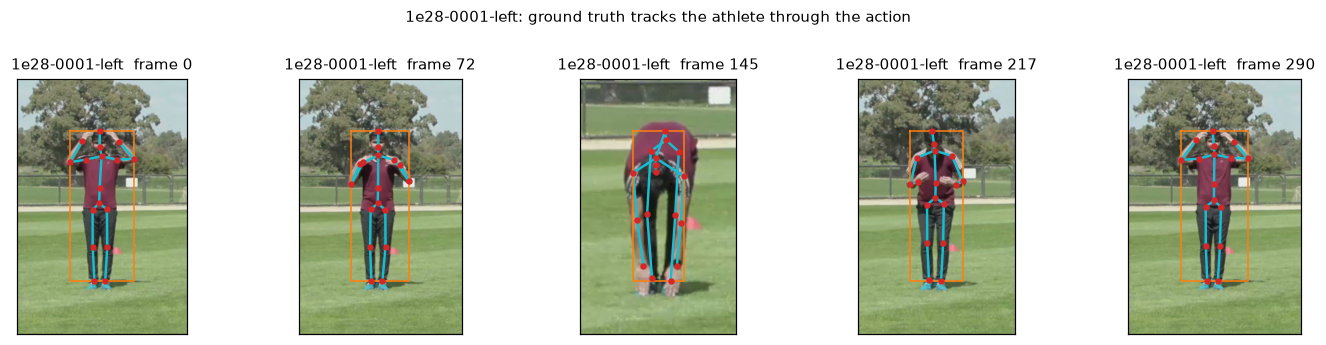

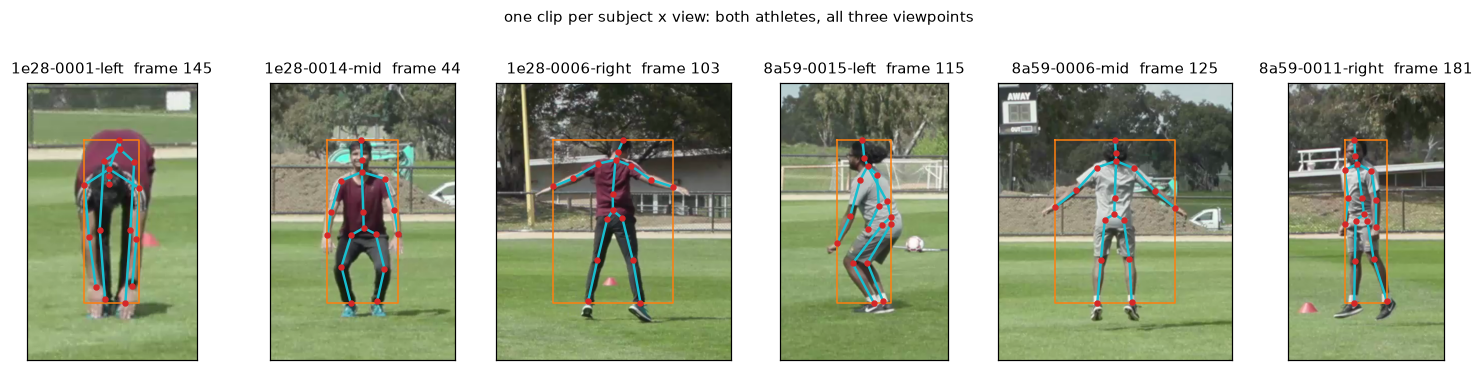

In [19]:
# A strip through time, and one frame from each subject/view combination we have.
fig, axes = plt.subplots(1, 5, figsize=(13, 3.0))
for ax, i in zip(axes, np.linspace(0, nframes - 1, 5).astype(int)):
    overlay(ax, s, cid, view, i)
plt.suptitle(f"{s}-{cid}-{view}: ground truth tracks the athlete through the action", y=1.02)
plt.tight_layout(); plt.show()

picks = []
for subj in subjects:
    for want in ("left", "mid", "right"):
        for (ss, cc), vs in sorted(views_of.items()):
            if ss == subj and want in vs:
                picks.append((ss, cc, want)); break
fig, axes = plt.subplots(1, len(picks), figsize=(2.3 * len(picks), 3.2))
for ax, (ss, cc, vv) in zip(axes, picks):
    overlay(ax, ss, cc, vv, frames[(ss, cc)][0] // 2)
plt.suptitle("one clip per subject x view: both athletes, all three viewpoints", y=1.03)
plt.tight_layout(); plt.show()

## 7. The missing-views problem, measured

Everything above says the data is high quality and internally consistent. This section is the
caveat, and it is the thing to know before planning any work on this folder.

The rig has three cameras. The calibration for all three is present for both subjects. But the
*footage* is only present for one view per clip.

clips: 60   views present per clip: {np.int64(1): 60}
total video files present: 60 of a possible 180 (33%)
clips with >= 2 views (triangulation possible): 0


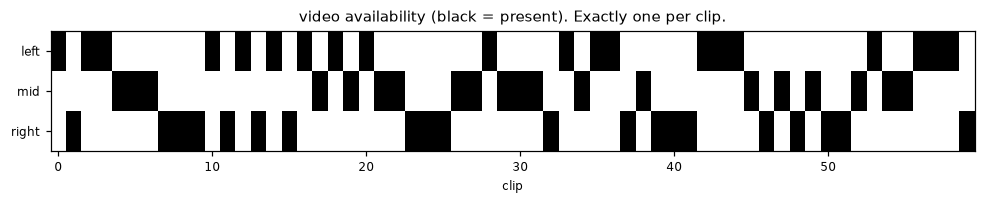

In [20]:
matrix = collections.defaultdict(dict)
for (ss, cc), vs in views_of.items():
    for want in ("left", "mid", "right"):
        matrix[(ss, cc)][want] = want in vs

have = np.array([[matrix[k][v] for v in ("left", "mid", "right")] for k in sorted(matrix)])
print(f"clips: {len(have)}   views present per clip: "
      f"{dict(collections.Counter(have.sum(1)))}")
print(f"total video files present: {have.sum()} of a possible {3*len(have)} "
      f"({100*have.sum()/(3*len(have)):.0f}%)")
print(f"clips with >= 2 views (triangulation possible): {(have.sum(1) >= 2).sum()}")

fig, ax = plt.subplots(figsize=(9, 1.9))
ax.imshow(have.T, aspect="auto", cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
ax.set(yticks=[0, 1, 2], yticklabels=["left", "mid", "right"], xlabel="clip",
       title="video availability (black = present). Exactly one per clip.")
plt.tight_layout(); plt.show()

**What this means in practice.**

* **Multi-view triangulation is off the table** for every clip here. Not one clip has two views.
* **Monocular lifting is still fully supported**, and well supported: you have a calibrated
  camera, exact 3D ground truth in a metric world frame, and a tight box. That is everything you
  need to train or evaluate an image → 3D method.
* The 3D annotations were produced from the *full* rig, so ground truth quality is unaffected by
  the missing footage — you simply cannot re-derive it yourself from what is here.

This connects directly to the ambiguity measured in `mhr_kinematics.ipynb` §10: fitting a body
to a single view reprojects beautifully while the 3D pose stays ~13–19 cm off, because each limb
can point toward or away from the camera. ASPset with three views would have resolved that;
ASPset as downloaded here cannot. If multi-view is what you need, re-fetch the `videos` archive
— `joints_3d`, `boxes` and `cameras` are already complete for all three views, and only ~2.7 GB
of extra footage is missing.

Also worth stating plainly about the split: with **2 subjects**, this is an evaluation set, not
a training set. Use it to measure; fetch `train`/`val` if you want to fit anything.

## 8. How ASPset maps onto MHR

Two conversions are needed to use this data with the MHR rig in this workspace: coordinates and
joint naming.

**Coordinates.** ASPset is mm with **+y down** (it is the left camera's frame); MHR is cm with
**+y up**. So $X_{\text{MHR}} = 0.1 \cdot \mathrm{diag}(1, -1, -1) \cdot X_{\text{ASPset}}$ —
negating y *and* z keeps the frame right-handed.

**Joints.** All 17 ASPset joints have an MHR counterpart, but the names differ substantially, and
two are approximations rather than identities.

In [21]:
ASPSET_TO_MHR = {
    "pelvis":         "root",         # MHR's root sits at the pelvis
    "spine":          "c_spine1",     # approximate: ASPset has 1 spine point, MHR has 4
    "neck":           "c_neck",
    "head":           "c_head",
    "head_top":       None,           # no MHR joint at the crown -- use a vertex, not a joint
    "left_shoulder":  "l_clavicle",
    "left_elbow":     "l_lowarm",
    "left_wrist":     "l_wrist",
    "right_shoulder": "r_clavicle",
    "right_elbow":    "r_lowarm",
    "right_wrist":    "r_wrist",
    "left_hip":       "l_upleg",
    "left_knee":      "l_lowleg",
    "left_ankle":     "l_foot",
    "right_hip":      "r_upleg",
    "right_knee":     "r_lowleg",
    "right_ankle":    "r_foot",
}

def aspset_to_mhr_world(points_mm):
    """ASPset world (mm, +y down) -> MHR world (cm, +y up), preserving handedness."""
    return 0.1 * points_mm * np.array([1.0, -1.0, -1.0])

print(f"{'ASPset joint':<16s} -> {'MHR joint':<14s}")
for a, m in ASPSET_TO_MHR.items():
    print(f"{a:<16s} -> {m if m else '(no equivalent)':<14s}")
print(f"\nmapped: {sum(v is not None for v in ASPSET_TO_MHR.values())}/17")

converted = aspset_to_mhr_world(XYZ[0])
print(f"\nframe 0 in MHR convention (cm, +y up):")
for name in ("head_top", "pelvis", "left_ankle"):
    print(f"  {name:<12s} {converted[L[name]].round(1)}")
print(f"stature: {converted[L['head_top']][1] - converted[L['left_ankle']][1]:.1f} cm "
      "(head above ankle, so +y is up as intended)")

ASPset joint     -> MHR joint     
pelvis           -> root          
spine            -> c_spine1      
neck             -> c_neck        
head             -> c_head        
head_top         -> (no equivalent)
left_shoulder    -> l_clavicle    
left_elbow       -> l_lowarm      
left_wrist       -> l_wrist       
right_shoulder   -> r_clavicle    
right_elbow      -> r_lowarm      
right_wrist      -> r_wrist       
left_hip         -> l_upleg       
left_knee        -> l_lowleg      
left_ankle       -> l_foot        
right_hip        -> r_upleg       
right_knee       -> r_lowleg      
right_ankle      -> r_foot        

mapped: 16/17

frame 0 in MHR convention (cm, +y up):
  head_top     [ -131.6    48.3 -1628. ]
  pelvis       [ -124.4   -18.6 -1622.2]
  left_ankle   [ -134.5  -101.3 -1619.5]
stature: 149.7 cm (head above ankle, so +y is up as intended)


Three caveats before you use that mapping for fitting:

1. **`spine` is not `c_spine1`.** ASPset has one thoracic point where MHR has four spine joints.
   Weight this correspondence low, or drop it.
2. **`head_top` has no joint equivalent.** MHR's `c_head` is inside the skull. Constrain the
   crown against a *mesh vertex* instead of a joint if you need it.
3. **Marker-based joint centres are not rig joint centres.** ASPset's "shoulder" comes from
   surface markers and MHR's `l_clavicle` is an anatomical rotation centre; expect a systematic
   few-cm offset that no pose parameters can absorb. Fit with that offset in mind rather than
   chasing it to zero.

The recipe for fitting MHR to a clip is then exactly §10 of `mhr_kinematics.ipynb`, with either
3D `Position` constraints (converted joints, the easy path — 3D ground truth is given) or 2D
`Projection` constraints using this dataset's real `K` and `[R|t]`.

## 9. Summary, and a loader

**What the folder is**

| | |
|---|---|
| dataset | ASPset-510, `test` split only |
| subjects | 2 (`8a59`, `1e28`), anonymised |
| clips | 60 (30 per subject), 13 708 frames, 4.6 min of motion |
| video | 3840×2160 @ 50 fps, Matroska, **one view per clip only** |
| annotations | 17 joints, 50 Hz, **millimetres, +y down**, zero missing markers |
| cameras | fixed 3-camera rig, shared world frame = the left camera; no distortion |
| boxes | tight bbox of the projected joints (verified to 0.01 px), *not* detections |
| size | 1.3 GB, of which 1.3 GB is video |

**Conventions, all verified in this notebook, not assumed**

* `uv = K[:3,:3] @ (E[:3,:3] @ X + E[:3,3])`, then divide by z. Reproduces `boxes` exactly.
* World origin = left camera; the subject sits 10–25 m away (median 18 m); y points down.
* Frame *i* of the video is frame *i* of the `.c3d` and row *i* of the `.csv`. No offsets.
* Bone lengths are stable to ~4% CV (worst ~8% at the shoulders), so the mocap is clean
  and gap-filled, but the points are surface-marker-derived, not anatomical joint centres.

**Gotchas**

1. The four `ASPset-510*` folders are one dataset in four archives. Do not delete any.
2. One view per clip → **no triangulation**. Re-fetch `videos` if you need multi-view.
3. `boxes` is derived from ground truth. Using it at inference time leaks the answer.
4. The subject is ~15% of frame height in 4K. Always crop.
5. Two subjects is an *evaluation* set. Fetch `train`/`val` to fit anything.
6. mm/y-down → MHR's cm/y-up needs `0.1 * diag(1, -1, -1)`.

In [22]:
class ASPset:
    """Minimal reader for the ASPset-510 layout, across the split-archive folders."""

    def __init__(self, root):
        self.mod = {}
        for d in sorted(pathlib.Path(root).glob("ASPset-510*")):
            for split in (p for p in d.iterdir() if p.is_dir()):
                for m in (p for p in split.iterdir() if p.is_dir()):
                    self.mod[m.name] = m
        self.clips = sorted({tuple(p.stem.split("-")) for p in self.mod["joints_3d"].rglob("*.c3d")})
        self.views = collections.defaultdict(set)
        for p in self.mod["videos"].rglob("*.mkv"):
            subj, clip, view = p.stem.split("-")
            self.views[(subj, clip)].add(view)

    def joints_3d(self, subject, clip):
        """(frames, 17, 3) in mm, +y down."""
        with open(self.mod["joints_3d"] / subject / f"{subject}-{clip}.c3d", "rb") as f:
            return np.array([p for _, p, _ in c3d.Reader(f).read_frames()])[:, :, :3]

    def camera(self, subject, view):
        d = json.loads((self.mod["cameras"] / subject / f"{subject}-{view}.json").read_text())
        return (np.array(d["intrinsic_matrix"]).reshape(3, 4),
                np.array(d["extrinsic_matrix"]).reshape(4, 4))

    def boxes(self, subject, clip, view):
        return np.loadtxt(self.mod["boxes"] / subject / f"{subject}-{clip}-{view}.csv",
                          delimiter=",", skiprows=1)

    def frame(self, subject, clip, view, index):
        cap = cv2.VideoCapture(str(self.mod["videos"] / subject / f"{subject}-{clip}-{view}.mkv"))
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)
        ok, img = cap.read(); cap.release()
        if not ok:
            raise IOError(f"could not decode frame {index}")
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def joints_2d(self, subject, clip, view):
        """(frames, 17, 2) pixels, by projecting the 3D ground truth."""
        K, E = self.camera(subject, view)
        pts = self.joints_3d(subject, clip)
        hom = np.concatenate([pts, np.ones(pts.shape[:2] + (1,))], -1)
        cam = hom @ E.T
        uvw = cam[..., :3] @ K[:, :3].T
        return uvw[..., :2] / uvw[..., 2:3]

    def joints_mhr(self, subject, clip):
        """(frames, 17, 3) in MHR convention: cm, +y up, right-handed."""
        return 0.1 * self.joints_3d(subject, clip) * np.array([1.0, -1.0, -1.0])


ds = ASPset(ASP)
print(f"{len(ds.clips)} clips, subjects {sorted({s for s, _ in ds.clips})}")
subj, clip = ds.clips[0]
view = sorted(ds.views[(subj, clip)])[0]
print(f"\n{subj}-{clip}-{view}")
print("  joints_3d  ", ds.joints_3d(subj, clip).shape, "mm, y-down")
print("  joints_mhr ", ds.joints_mhr(subj, clip).shape, "cm, y-up")
print("  joints_2d  ", ds.joints_2d(subj, clip, view).shape, "px")
print("  boxes      ", ds.boxes(subj, clip, view).shape)
print("  frame      ", ds.frame(subj, clip, view, 0).shape)

uv = ds.joints_2d(subj, clip, view)[0]
bx = ds.boxes(subj, clip, view)[0]
print(f"\nconsistency: projected-joint bbox vs boxes CSV -> "
      f"{np.abs(np.array([uv[:,0].min(), uv[:,1].min(), uv[:,0].max(), uv[:,1].max()]) - bx).max():.4f} px")

60 clips, subjects ['1e28', '8a59']

1e28-0001-left
  joints_3d   (291, 17, 3) mm, y-down
  joints_mhr  (291, 17, 3) cm, y-up
  joints_2d   (291, 17, 2) px
  boxes       (291, 4)


  frame       (2160, 3840, 3)

consistency: projected-joint bbox vs boxes CSV -> 0.0046 px
